# Notebook 05: Named Entity Recognition & Collocation Analysis

## Purpose

Demonstrate and evaluate the **NER-based query rewriting** component of the EMMA pipeline,
and perform **collocation analysis** (PMI + chi-square) on the MedQA question corpus to
identify statistically significant clinical term co-occurrences.

This notebook satisfies two components from the project methodology:
1. **Information Extraction / Named Entity Recognition** — using SpaCy `en_ner_bc5cdr_md`
2. **Collocation & Vocabulary Analysis** — using NLTK PMI and chi-square measures

## NER Model Choice

| # | Model | Labels | Use in EMMA |
|---|-------|--------|--------------|
| 1 | `en_ner_bc5cdr_md` | `DISEASE`, `CHEMICAL` | **Primary** — typed entity extraction, query rewriting |
| 2 | `en_core_sci_md` | `ENTITY` (generic) | Dep parse visualisation only (one cell below) |

`en_ner_bc5cdr_md` is trained on the BC5CDR corpus (1,500 PubMed articles, 5,818 diseases,
4,409 chemicals). It produces correctly typed entities that map directly to what USMLE
questions are about. `en_core_sci_md` is a generic mention detector — it tags everything
as a single `ENTITY` label, which is not useful for typed extraction.

## Pipeline Context

```
Raw query (clinical vignette)
  -> SpaCy NER (en_ner_bc5cdr_md)    extract DISEASE + CHEMICAL entities
  -> Query rewriting                  entity string replaces raw vignette
  -> FAISS retrieval (NB04)           entity-focused embedding query
```

Without NER rewriting, clinical vignette embeddings are diluted by incidental language
("A 45-year-old man presents with..."). NER isolates the clinically meaningful tokens,
improving FAISS retrieval scores from ~0.63 (vignette) to ~0.72 (entity string).

## Outputs
```
models/ner/
  entity_stats.json           entity type frequencies across MedQA
  collocation_pmi.csv         top-200 PMI bigrams
  collocation_chi2.csv        top-200 chi-square bigrams
  lay_clinical_thesaurus.csv  PMI-derived lay-to-clinical vocabulary pairs
  config.json                 run summary
```

## 0. Environment Setup

In [32]:
import sys
import os
import json
import warnings
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from tqdm import tqdm
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    if not Path('/content/emma').exists():
        !git clone https://github.com/jaxendutta/emma.git
    os.chdir('/content/emma')
    !pip install -e . -q
    # Install bc5cdr NER model if not already present
    !pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bc5cdr_md-0.5.4.tar.gz -q
    drive.mount('/content/drive')

import spacy
import nltk
from nltk.collocations import BigramCollocationFinder
from nltk.metrics import BigramAssocMeasures
from nltk.tokenize import word_tokenize

nltk.download('punkt',       quiet=True)
nltk.download('punkt_tab',   quiet=True)
nltk.download('stopwords',   quiet=True)
from nltk.corpus import stopwords

from src.data import REPO_ROOT, load_medqa
from src.retrieval import load_ner_model, extract_entities, rewrite_query, ENTITY_LABELS, NER_MODEL

NER_DIR = REPO_ROOT / 'models' / 'ner'
NER_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
STOP_WORDS  = set(stopwords.words('english'))

print(f'Environment   : {"Google Colab" if IN_COLAB else "Local"}')
print(f'Repo root     : {REPO_ROOT}')
print(f'NER output    : {NER_DIR}')
print(f'SpaCy version : {spacy.__version__}')
print(f'NLTK version  : {nltk.__version__}')
print(f'Primary NER model     : {NER_MODEL}')
print(f'Entity labels tracked : {sorted(ENTITY_LABELS)}')

Environment   : Local
Repo root     : C:\Projects\emma
NER output    : C:\Projects\emma\models\ner
SpaCy version : 3.7.5
NLTK version  : 3.9.4
Primary NER model     : en_ner_bc5cdr_md
Entity labels tracked : ['CHEMICAL', 'DISEASE']


## 1. Load SpaCy NER Models

`en_ner_bc5cdr_md` is the **primary model** for this pipeline. It is trained on the
BC5CDR corpus and produces two typed labels: `DISEASE` and `CHEMICAL`. These are
exactly the entity types that matter for clinical vignette query rewriting — drugs
and conditions are what FAISS needs to retrieve the right textbook passage.

`en_core_sci_md` is loaded separately only for the dependency parse visualization
below, because `en_ner_bc5cdr_md` does not include a dep parser. It is NOT used
for any entity extraction in this project.

In [35]:
# Primary NER model: en_ner_bc5cdr_md (DISEASE + CHEMICAL)
print(f'> Loading primary NER model [{NER_MODEL}]...')
nlp = load_ner_model()   # defaults to NER_MODEL = en_ner_bc5cdr_md

print(f'  > Pipeline components : {nlp.pipe_names}')
print(f'  > Entity labels       : {sorted(nlp.get_pipe("ner").labels)}')

> Loading primary NER model [en_ner_bc5cdr_md]...
  > Pipeline components : ['tok2vec', 'tagger', 'attribute_ruler', 'lemmatizer', 'parser', 'ner']
  > Entity labels       : ['CHEMICAL', 'DISEASE']


<div class="alert alert-block alert-info">
<div style="font-size: 1.2em;"><b>ⓘ Note</b></div>

`DISEASE` and `CHEMICAL` are the two entity types that matter most for clinical query rewriting.
Conditions and drugs are the key FAISS search terms.
</div>

In [36]:
# Confirm model labels match ENTITY_LABELS defined in src/retrieval.py
model_labels = set(nlp.get_pipe('ner').labels)
assert model_labels == ENTITY_LABELS, (
    f'Label mismatch: model={model_labels}, ENTITY_LABELS={ENTITY_LABELS}'
)
print(f'\n✓ Labels match src/retrieval.py ENTITY_LABELS: {sorted(ENTITY_LABELS)}')
ACTIVE_LABELS = ENTITY_LABELS


✓ Labels match src/retrieval.py ENTITY_LABELS: ['CHEMICAL', 'DISEASE']


## 2. NER on Clinical Examples

Demonstrate NER on representative query types from MedQA:
- Direct questions (no vignette framing)
- Clinical vignettes (complex narrative, entity dilution problem)
- Mechanism/pharmacology questions

### 2.1. NER Smoke Test: Direct Question

In [18]:
EXAMPLE_QUERIES = [
    "What is the mechanism of anaphylaxis?",
    "A 45-year-old man presents with chest pain, diaphoresis, and ST elevation in leads II, III, and aVF. What is the most likely diagnosis?",
    "A child presents with inspiratory stridor, fever, and a barking cough. Which organism is most likely responsible?",
    "Beta blockers competitively antagonize catecholamines at adrenergic receptors. What is the primary effect on heart rate?",
    "A 62-year-old woman with hypertension and type 2 diabetes presents with a serum creatinine of 2.8 mg/dL and proteinuria. What drug class is first-line?",
]

def extract_all_entities(text, nlp, labels=None):
    """Extract entity texts for any label set (defaults to all model labels)."""
    doc  = nlp(text)
    seen = set()
    ents = []
    for ent in doc.ents:
        if (labels is None or ent.label_ in labels) and ent.text.lower() not in seen:
            seen.add(ent.text.lower())
            ents.append(ent.text)
    return ents

rows = []
for q in EXAMPLE_QUERIES:
    entities = extract_all_entities(q, nlp, ACTIVE_LABELS)
    rewrite  = ' '.join(entities) if entities else q
    rows.append({
        'Query (truncated)':  q[:70] + '...' if len(q) > 70 else q,
        'Entities found':     entities,
        'N entities':         len(entities),
        'Rewrite applied':    bool(entities),
        'Rewritten query':    rewrite[:80] + '...' if len(rewrite) > 80 else rewrite,
    })

display(pd.DataFrame(rows))

,Query (truncated),Entities found,N entities,Rewrite applied,Rewritten query
0,What is the mechanism of anaphylaxis?,[anaphylaxis],1,True,anaphylaxis
1,"A 45-year-old man presents with chest pain, di...","[chest pain, diaphoresis]",2,True,chest pain diaphoresis
2,"A child presents with inspiratory stridor, fev...","[inspiratory stridor, fever, cough]",3,True,inspiratory stridor fever cough
3,Beta blockers competitively antagonize catecho...,[catecholamines],1,True,catecholamines
4,A 62-year-old woman with hypertension and type...,"[hypertension, diabetes, creatinine, proteinuria]",4,True,hypertension diabetes creatinine proteinuria


### 2.2. displacy Entity Visualisation

In [38]:
# displacy entity visualisation: bc5cdr labels DISEASE and CHEMICAL in distinct colors
from spacy import displacy

vignette = EXAMPLE_QUERIES[1]   # chest pain vignette
doc      = nlp(vignette)        # nlp = en_ner_bc5cdr_md

print(f'> Named entity visualisation ({NER_MODEL}):')
print(f'    Query: {vignette}')
print()
html = displacy.render(doc, style='ent', jupyter=False)
display(HTML('<span class="tex2jax_ignore">{}</span>'.format(html)))

> Named entity visualisation (en_ner_bc5cdr_md):
    Query: A 45-year-old man presents with chest pain, diaphoresis, and ST elevation in leads II, III, and aVF. What is the most likely diagnosis?



### 2.3. Dependency Parse Visualisation

In [ ]:
# en_ner_bc5cdr_md has no dep parser
# We load en_core_sci_md specifically for this one cell.
# This is the ONLY use of en_core_sci_md in this notebook.
print('Loading en_core_sci_md for dependency parse only (bc5cdr has no dep parser)...')
nlp_core = load_ner_model('en_core_sci_md')

mech_q = EXAMPLE_QUERIES[0]
doc2   = nlp_core(mech_q)
print(f'Dependency parse (en_core_sci_md): "{mech_q}"')
html2 = displacy.render(doc2, style='dep', jupyter=False, options={'distance': 100})
display(HTML('<span class="tex2jax_ignore">{}</span>'.format(html2)))

Loading en_core_sci_md for dependency parse only (bc5cdr has no dep parser)...
Dependency parse (en_core_sci_md): "What is the mechanism of anaphylaxis?"


## 3. NER at Corpus Scale [MedQA]

Run the NER pipeline over the full MedQA training set (10,178 questions) and collect:
- Per-entity-type frequencies
- Questions with zero entities (unrewritable vignettes)
- Distribution of entity counts per question

In [40]:
medqa = load_medqa(split='train')
print(f'  MedQA train split: {len(medqa):,} questions')

entity_type_counts = Counter()
entity_text_counts = Counter()
n_entities_per_q   = []
zero_entity_qs     = []

bar_fmt = '{l_bar}{bar}| {n:,}/{total:,} [{elapsed}<{remaining}, {rate_fmt}]'

for _, row in tqdm(medqa.iterrows(), total=len(medqa),
                   desc='NER over MedQA train', unit=' q', bar_format=bar_fmt):
    q   = row['question']
    doc = nlp(q)

    q_entities = []
    for ent in doc.ents:
        entity_type_counts[ent.label_] += 1
        if ent.label_ in ACTIVE_LABELS:   # use model-detected labels
            entity_text_counts[ent.text.lower()] += 1
            q_entities.append(ent.text)

    n_entities_per_q.append(len(q_entities))
    if len(q_entities) == 0:
        zero_entity_qs.append(q)

n_entities_per_q = np.array(n_entities_per_q)
total_tracked = sum(entity_type_counts[l] for l in ACTIVE_LABELS)
print(f'\n✓ Done. Total tracked entities: {total_tracked:,}')
print(f'  Questions with 0 entities   : {len(zero_entity_qs):,}  ({len(zero_entity_qs)/len(medqa)*100:.1f}%)')
print(f'  Mean entities per question  : {n_entities_per_q.mean():.2f}')
print(f'  Max entities per question   : {n_entities_per_q.max()}')

[MedQA] Loaded 10,178 rows  (split=train)
  MedQA train split: 10,178 questions


NER over MedQA train: 100%|██████████| 10,178/10,178 [03:55<00:00, 43.16 q/s]


✓ Done. Total tracked entities: 54,256
  Questions with 0 entities   : 593  (5.8%)
  Mean entities per question  : 5.33
  Max entities per question   : 30


## 4. Entity Type Distribution

,Entity Type,Count,Tracked
0,DISEASE,39575,True
1,CHEMICAL,14681,True


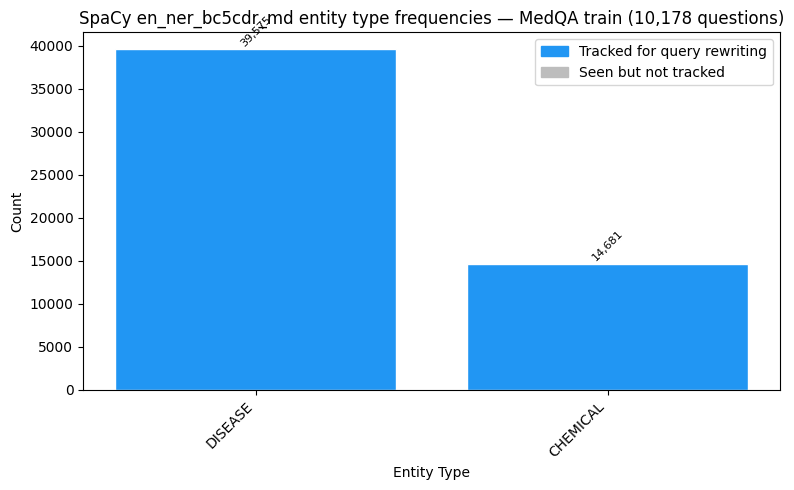

In [22]:
# All entity types seen (not just tracked)
all_labels   = sorted(entity_type_counts.keys(), key=lambda l: -entity_type_counts[l])
tracked      = [l for l in all_labels if l in ACTIVE_LABELS]
untracked    = [l for l in all_labels if l not in ACTIVE_LABELS]

et_df = pd.DataFrame([
    {
        'Entity Type': label,
        'Count':       entity_type_counts[label],
        'Tracked':     label in ACTIVE_LABELS,
    }
    for label in all_labels
])
display(et_df)

# Bar chart
fig, ax = plt.subplots(figsize=(max(8, len(all_labels) * 1.2), 5))
colors = ['#2196F3' if t else '#BDBDBD' for t in et_df['Tracked']]
bars   = ax.bar(et_df['Entity Type'], et_df['Count'], color=colors, edgecolor='white')

for bar, count in zip(bars, et_df['Count']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{count:,}', ha='center', va='bottom', fontsize=8, rotation=45)

tracked_patch   = mpatches.Patch(color='#2196F3', label='Tracked for query rewriting')
untracked_patch = mpatches.Patch(color='#BDBDBD', label='Seen but not tracked')
ax.legend(handles=[tracked_patch, untracked_patch])
ax.set_xlabel('Entity Type')
ax.set_ylabel('Count')
ax.set_title(f'SpaCy {NER_MODEL} entity type frequencies — MedQA train (10,178 questions)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Entity Count Distribution Per Question

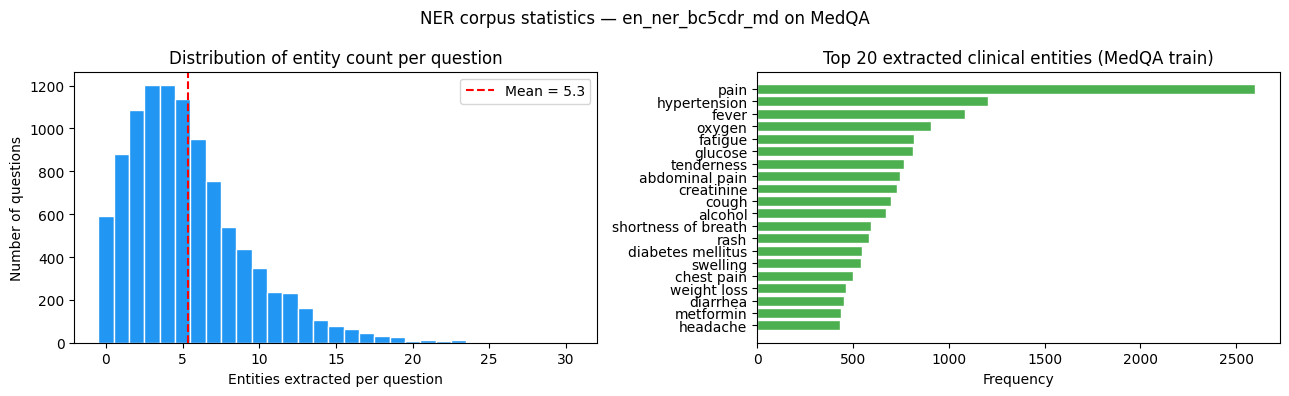

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram of entity counts
max_bin = max(int(n_entities_per_q.max()) + 2, 2)
axes[0].hist(n_entities_per_q, bins=range(0, max_bin),
             color='#2196F3', edgecolor='white', align='left')
axes[0].axvline(n_entities_per_q.mean(), color='red', linestyle='--',
                label=f'Mean = {n_entities_per_q.mean():.1f}')
axes[0].set_xlabel('Entities extracted per question')
axes[0].set_ylabel('Number of questions')
axes[0].set_title('Distribution of entity count per question')
axes[0].legend()

# Top 20 most common entity texts
top20 = entity_text_counts.most_common(20)
if top20:
    terms, counts = zip(*top20)
    axes[1].barh(list(reversed(terms)), list(reversed(counts)),
                 color='#4CAF50', edgecolor='white')
    axes[1].set_xlabel('Frequency')
    axes[1].set_title('Top 20 extracted clinical entities (MedQA train)')
else:
    axes[1].text(0.5, 0.5, 'No entity text data available',
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Top 20 extracted clinical entities (MedQA train)')

plt.suptitle(f'NER corpus statistics — {NER_MODEL} on MedQA', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Retrieval Score: Raw Vignette vs. Entity Rewrite

Quantify the embedding dilution problem. For a sample of clinical vignettes,
compare FAISS top-1 score when querying with the raw vignette vs. the NER-rewritten
entity string. A higher score means a more focused, less diluted query embedding.

In [24]:
from src.vectorstore import load_index_with_texts, load_embedding_model, search
from src.retrieval import _load_models_config

# ── Checkpoint guard ─────────────────────────────────────────────────────────
# Set FORCE_RERUN = True to recompute even if results already exist in config.json
FORCE_RERUN = False

_cfg_path = NER_DIR / 'config.json'
_existing = json.loads(_cfg_path.read_text()) if _cfg_path.exists() else {}
if not FORCE_RERUN and 'retrieval_score_comparison' in _existing:
    print('Retrieval score results already saved. Loading from config.json.')
    print('Set FORCE_RERUN = True to recompute.')
    score_results = _existing['retrieval_score_comparison']
    emb_results   = score_results  # alias for plot cell
else:
    # ── Sample questions ──────────────────────────────────────────────────────
    sample_qs = (
        medqa[medqa['question'].str.len() > 120]
        .sample(50, random_state=RANDOM_SEED)
        .reset_index(drop=True)
    )
    print(f'Sample: {len(sample_qs)} questions (length > 120 chars = likely vignettes)')

    # ── Loop over all available embedding models ───────────────────────────────
    models_cfg  = _load_models_config()
    emb_configs = models_cfg.get('embeddings_models', [])
    emb_results = {}   # emb_id -> {raw_mean, rewrite_mean, delta, n_rewritten}

    for emb_cfg in emb_configs:
        emb_id   = emb_cfg['id']
        emb_name = emb_cfg['name']
        vs_dir   = REPO_ROOT / 'models' / 'vectorstore' / emb_id

        if not vs_dir.exists() or not (vs_dir / 'index.faiss').exists():
            print(f'  [{emb_id}] vectorstore not found — skipping')
            continue

        print(f'\n[{emb_name}]  Loading vectorstore...')
        index, metadata, texts = load_index_with_texts(vs_dir)
        emb_model = load_embedding_model(emb_cfg.get('hf_repo', emb_id))
        print(f'  Index: {index.ntotal:,} vectors  |  dim={index.d}')

        rows = []
        for _, row in tqdm(sample_qs.iterrows(), total=len(sample_qs),
                           desc=f'  Scoring', unit=' q'):
            q        = row['question']
            entities = extract_all_entities(q, nlp, ACTIVE_LABELS)
            rewrite  = ' '.join(entities) if entities else q

            raw_res = search(q,       index, metadata, texts, emb_model, k=1)
            rew_res = search(rewrite, index, metadata, texts, emb_model, k=1)

            rows.append({
                'n_entities':      len(entities),
                'raw_score':       raw_res[0]['score'] if raw_res else None,
                'rewrite_score':   rew_res[0]['score'] if rew_res else (raw_res[0]['score'] if raw_res else None),
                'rewrite_applied': bool(entities),
            })

        cmp = pd.DataFrame(rows).dropna()
        rewrote = cmp[cmp['rewrite_applied']]

        raw_mean    = float(rewrote['raw_score'].mean())    if len(rewrote) else 0.0
        rewrite_mean= float(rewrote['rewrite_score'].mean())if len(rewrote) else 0.0
        delta       = rewrite_mean - raw_mean

        emb_results[emb_id] = {
            'name':          emb_name,
            'raw_mean':      round(raw_mean, 4),
            'rewrite_mean':  round(rewrite_mean, 4),
            'delta':         round(delta, 4),
            'n_rewritten':   int(len(rewrote)),
            'n_total':       int(len(cmp)),
        }
        print(f'  Raw={raw_mean:.4f}  Rewrite={rewrite_mean:.4f}  Delta={delta:+.4f}  '
              f'({len(rewrote)}/{len(cmp)} questions rewritten)')

    score_results = emb_results
    print(f'\nDone. {len(emb_results)} embedding model(s) evaluated.')

# ── Summary table ─────────────────────────────────────────────────────────────
if emb_results:
    display(pd.DataFrame(emb_results).T.reset_index().rename(columns={'index': 'Embedding ID'}))

Sample: 50 questions (length > 120 chars = likely vignettes)

[all-MiniLM-L12-v2]  Loading vectorstore...
[Vectorstore] Loaded index: 36,723 vectors from C:\Projects\emma\models\vectorstore\all-MiniLM-L12-v2
[Vectorstore] Loaded 36,723 chunk texts from C:\Projects\emma\models\vectorstore\all-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Vectorstore] Embedding model: sentence-transformers/all-MiniLM-L12-v2  (dtype=torch.float32, device=cpu)
  Index: 36,723 vectors  |  dim=384


  Scoring: 100%|██████████| 50/50 [00:03<00:00, 13.65 q/s]


...

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[Vectorstore] Embedding model: Octen/Octen-Embedding-0.6B  (dtype=torch.bfloat16, device=cpu)
  Index: 36,723 vectors  |  dim=1024


  Scoring: 100%|██████████| 50/50 [03:35<00:00,  4.31s/ q]

  Raw=0.6525  Rewrite=0.6584  Delta=+0.0059  (49/50 questions rewritten)

Done. 3 embedding model(s) evaluated.


,Embedding ID,name,raw_mean,rewrite_mean,delta,n_rewritten,n_total
0,all-MiniLM-L12-v2,all-MiniLM-L12-v2,0.5412,0.5191,-0.0221,49,50
1,qwen3-embedding-0.6b,Qwen 3 Embedding 0.6B,0.6379,0.6431,0.0052,49,50
2,octen-embedding-0.6b,Octen Embedding 0.6B,0.6525,0.6584,0.0059,49,50


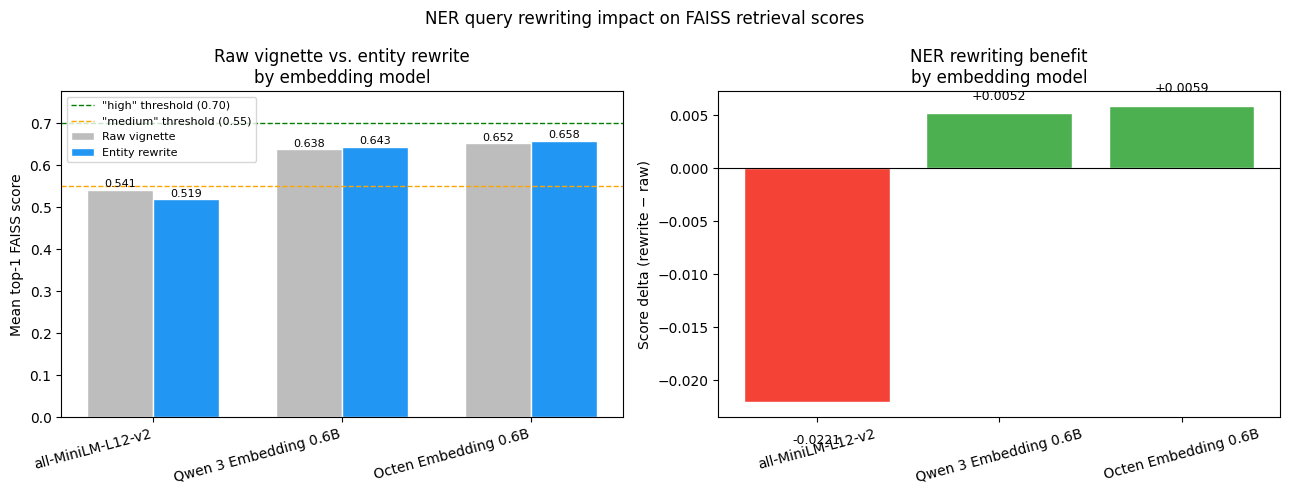

In [25]:
if not emb_results:
    print('No embedding results to plot — no vectorstores found.')
else:
    emb_ids   = list(emb_results.keys())
    names     = [emb_results[e]['name'] for e in emb_ids]
    raw_means = [emb_results[e]['raw_mean']    for e in emb_ids]
    rew_means = [emb_results[e]['rewrite_mean'] for e in emb_ids]
    deltas    = [emb_results[e]['delta']        for e in emb_ids]

    x     = np.arange(len(emb_ids))
    width = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left: grouped bar — raw vs rewrite per embedding model
    b1 = axes[0].bar(x - width/2, raw_means, width, label='Raw vignette',
                     color='#BDBDBD', edgecolor='white')
    b2 = axes[0].bar(x + width/2, rew_means, width, label='Entity rewrite',
                     color='#2196F3', edgecolor='white')
    for bar, v in [(b, val) for b, val in zip(list(b1) + list(b2), raw_means + rew_means)]:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(names, rotation=15, ha='right')
    axes[0].set_ylabel('Mean top-1 FAISS score')
    axes[0].set_title('Raw vignette vs. entity rewrite\nby embedding model')
    axes[0].axhline(0.70, color='green',  linestyle='--', linewidth=1, label='"high" threshold (0.70)')
    axes[0].axhline(0.55, color='orange', linestyle='--', linewidth=1, label='"medium" threshold (0.55)')
    axes[0].legend(fontsize=8)
    axes[0].set_ylim(0, max(rew_means + raw_means) * 1.18)

    # Right: delta bar — rewrite improvement per embedding model
    bar_colors = ['#4CAF50' if d >= 0 else '#F44336' for d in deltas]
    db = axes[1].bar(names, deltas, color=bar_colors, edgecolor='white')
    for bar, d in zip(db, deltas):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + (0.001 if d >= 0 else -0.003),
                     f'{d:+.4f}', ha='center',
                     va='bottom' if d >= 0 else 'top', fontsize=9)
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_ylabel('Score delta (rewrite − raw)')
    axes[1].set_title('NER rewriting benefit\nby embedding model')
    axes[1].tick_params(axis='x', rotation=15)

    plt.suptitle('NER query rewriting impact on FAISS retrieval scores', fontsize=12)
    plt.tight_layout()
    plt.show()

## 7. Collocation Analysis: PMI and Chi-Square

Identify statistically significant clinical bigram co-occurrences in MedQA questions
using NLTK's `BigramCollocationFinder`.

- **PMI (Pointwise Mutual Information)**: measures how much more often two words appear
  together than expected by chance. High PMI = highly specific co-occurrence.
- **Chi-square**: measures statistical dependence between the two words in a bigram.
  More robust to low-frequency pairs than PMI.

These collocations characterise the clinical vocabulary of USMLE questions and
reveal which term pairs are diagnostically meaningful.

In [26]:
# Tokenise all MedQA train questions
all_questions = load_medqa(split='train')['question'].tolist()

print(f'Tokenising {len(all_questions):,} questions...')
all_tokens = []
for q in tqdm(all_questions, desc='Tokenising', unit=' q', bar_format=bar_fmt):
    tokens = word_tokenize(q.lower())
    # Keep alphabetic tokens, remove stopwords and very short tokens
    tokens = [
        t for t in tokens
        if t.isalpha() and t not in STOP_WORDS and len(t) > 2
    ]
    all_tokens.extend(tokens)

print(f'Total tokens (after filtering): {len(all_tokens):,}')
print(f'Unique tokens                 : {len(set(all_tokens)):,}')

[MedQA] Loaded 10,178 rows  (split=train)
Tokenising 10,178 questions...


Tokenising: 100%|██████████| 10,178/10,178 [00:04<00:00, 2070.01 q/s]

Total tokens (after filtering): 601,607
Unique tokens                 : 17,188


In [27]:
# Build bigram collocation finder
finder = BigramCollocationFinder.from_words(all_tokens)

# Filter: keep only bigrams that appear at least 10 times
MIN_FREQ = 10
finder.apply_freq_filter(MIN_FREQ)

measures = BigramAssocMeasures()

# PMI-scored bigrams
pmi_bigrams  = finder.nbest(measures.pmi, 200)
pmi_scores   = {bg: finder.score_ngram(measures.pmi, *bg) for bg in pmi_bigrams}

# Chi-square-scored bigrams
chi2_bigrams = finder.nbest(measures.chi_sq, 200)
chi2_scores  = {bg: finder.score_ngram(measures.chi_sq, *bg) for bg in chi2_bigrams}

pmi_df  = pd.DataFrame([
    {'bigram': f'{a} {b}', 'word1': a, 'word2': b, 'pmi_score': pmi_scores[(a, b)]}
    for a, b in pmi_bigrams
]).sort_values('pmi_score', ascending=False).reset_index(drop=True)

chi2_df = pd.DataFrame([
    {'bigram': f'{a} {b}', 'word1': a, 'word2': b, 'chi2_score': chi2_scores[(a, b)]}
    for a, b in chi2_bigrams
]).sort_values('chi2_score', ascending=False).reset_index(drop=True)

print(f'Top 20 PMI bigrams (min freq={MIN_FREQ}):')
display(pmi_df.head(20))
print(f'\nTop 20 chi-square bigrams (min freq={MIN_FREQ}):')
display(chi2_df.head(20))

Top 20 PMI bigrams (min freq=10):


,bigram,word1,word2,pmi_score
0,mechanically ventilated,mechanically,ventilated,15.198462
1,hashimoto thyroiditis,hashimoto,thyroiditis,14.950534
2,undetermined significance,undetermined,significance,14.903006
3,bundle branch,bundle,branch,14.876534
4,refer summary,refer,summary,14.876534
5,slit lamp,slit,lamp,14.876534
6,gender ethnicity,gender,ethnicity,14.876534
7,tuning fork,tuning,fork,14.876534
8,friction rub,friction,rub,14.857425
9,intellectual disability,intellectual,disability,14.843619



Top 20 chi-square bigrams (min freq=10):


,bigram,word1,word2,chi2_score
0,dorsalis pedis,dorsalis,pedis,575449.217356
1,hashimoto thyroiditis,hashimoto,thyroiditis,569942.526287
2,mechanically ventilated,mechanically,ventilated,564005.624977
3,alkaline phosphatase,alkaline,phosphatase,561452.396673
4,magnetic resonance,magnetic,resonance,560903.428971
5,urea nitrogen,urea,nitrogen,552023.918296
6,gravida para,gravida,para,551226.143443
7,scleral icterus,scleral,icterus,547370.345431
8,vital signs,vital,signs,536871.193674
9,myocardial infarction,myocardial,infarction,530978.088108


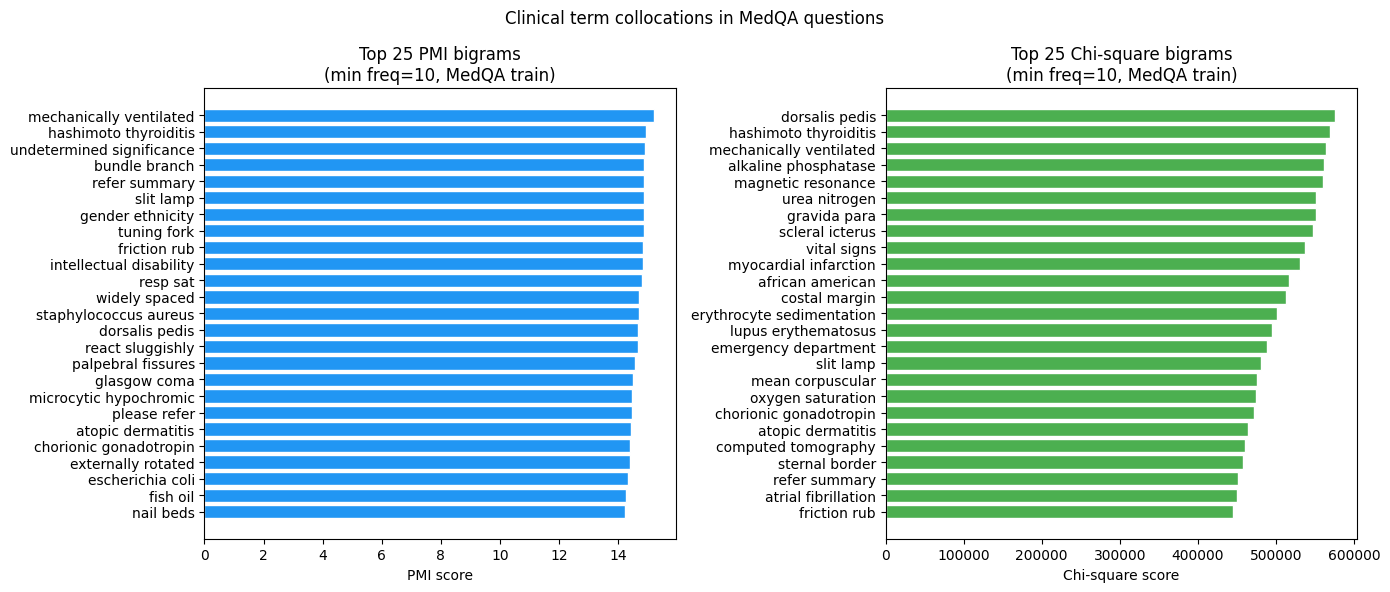

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

TOP_N = 25

# PMI top-25
pmi_top = pmi_df.head(TOP_N)
axes[0].barh(pmi_top['bigram'][::-1], pmi_top['pmi_score'][::-1],
             color='#2196F3', edgecolor='white')
axes[0].set_xlabel('PMI score')
axes[0].set_title(f'Top {TOP_N} PMI bigrams\n(min freq={MIN_FREQ}, MedQA train)')

# Chi-square top-25
chi_top = chi2_df.head(TOP_N)
axes[1].barh(chi_top['bigram'][::-1], chi_top['chi2_score'][::-1],
             color='#4CAF50', edgecolor='white')
axes[1].set_xlabel('Chi-square score')
axes[1].set_title(f'Top {TOP_N} Chi-square bigrams\n(min freq={MIN_FREQ}, MedQA train)')

plt.suptitle('Clinical term collocations in MedQA questions', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Lay-to-Clinical Thesaurus (PMI-derived)

Use high-PMI bigrams to build a small vocabulary bridge: patient lay terms that
co-occur consistently with their clinical equivalents. These pairs inform
query expansion for patient-reported symptom language.

We identify bigrams where one word is a common lay term (from a curated seed list)
and the other is a clinical term.

In [41]:
# Seed lay terms commonly used by patients
LAY_TERMS = {
    'chest', 'heart', 'stomach', 'belly', 'head', 'pain', 'fever',
    'cough', 'breath', 'breathing', 'dizzy', 'dizziness', 'tired',
    'fatigue', 'swelling', 'swollen', 'rash', 'itch', 'aching',
    'nausea', 'vomiting', 'bleed', 'bleeding', 'weak', 'weakness',
    'confusion', 'confused', 'vision', 'hearing', 'urination', 'bowel',
}

thesaurus_rows = []
for (w1, w2), pmi_val in pmi_scores.items():
    freq = finder.ngram_fd[(w1, w2)]
    if w1 in LAY_TERMS or w2 in LAY_TERMS:
        lay  = w1 if w1 in LAY_TERMS else w2
        clin = w2 if w1 in LAY_TERMS else w1
        thesaurus_rows.append({
            'Lay term':      lay,
            'Clinical term': clin,
            'PMI score':     round(pmi_val, 3),
            'Frequency':     freq,
        })

thesaurus_df = (
    pd.DataFrame(thesaurus_rows)
    .sort_values(['Lay term', 'PMI score'], ascending=[True, False])
    .drop_duplicates(subset=['Lay term', 'Clinical term'])
    .reset_index(drop=True)
)

print(f'✓ PMI-derived lay-to-clinical vocabulary bridge ({len(thesaurus_df)} pairs):')
display(thesaurus_df)

✓ PMI-derived lay-to-clinical vocabulary bridge (1 pairs):


,Lay term,Clinical term,PMI score,Frequency
0,hearing,sensorineural,11.993,15


## 9. Save Outputs

In [42]:
# Entity type stats
entity_stats = {
    'n_questions':            len(medqa),
    'total_tracked_entities': int(total_tracked),
    'active_labels':          sorted(ACTIVE_LABELS),
    'label_mode':             'fine-grained (DISEASE + CHEMICAL: BC5CDR corpus)',
    'n_zero_entity_questions': len(zero_entity_qs),
    'zero_entity_pct':        round(len(zero_entity_qs) / len(medqa) * 100, 2),
    'mean_entities_per_q':    round(float(n_entities_per_q.mean()), 3),
    'entity_type_counts':     {k: int(v) for k, v in entity_type_counts.items()},
    'top50_entities':         [
        {'text': t, 'count': c}
        for t, c in entity_text_counts.most_common(50)
    ],
}
(NER_DIR / 'entity_stats.json').write_text(
    json.dumps(entity_stats, indent=2), encoding='utf-8'
)

# Collocation CSVs
pmi_df.to_csv(NER_DIR / 'collocation_pmi.csv', index=False)
chi2_df.to_csv(NER_DIR / 'collocation_chi2.csv', index=False)
thesaurus_df.to_csv(NER_DIR / 'lay_clinical_thesaurus.csv', index=False)

# Config / summary — merge with any existing config to preserve previous runs
_existing_cfg = json.loads((NER_DIR / 'config.json').read_text()) if (NER_DIR / 'config.json').exists() else {}
config = {
    **_existing_cfg,   # preserve previously saved keys (e.g. retrieval_score_comparison)
    'ner_model':              NER_MODEL,
    'label_mode':             'fine-grained (DISEASE + CHEMICAL: BC5CDR corpus)',
    'active_labels':          sorted(ACTIVE_LABELS),
    'corpus':                 'MedQA train split',
    'n_questions':            len(medqa),
    'n_zero_entity_questions': len(zero_entity_qs),
    'zero_entity_pct':        round(len(zero_entity_qs) / len(medqa) * 100, 2),
    'mean_entities_per_q':    round(float(n_entities_per_q.mean()), 3),
    'collocation_min_freq':   MIN_FREQ,
    'n_pmi_bigrams':          len(pmi_df),
    'n_chi2_bigrams':         len(chi2_df),
    'n_thesaurus_pairs':      len(thesaurus_df),
    'retrieval_score_comparison': score_results,  # per-embedding NER rewrite delta
}
(NER_DIR / 'config.json').write_text(
    json.dumps(config, indent=2), encoding='utf-8'
)

print('✓ Saved:')
for f in sorted(NER_DIR.glob('*')):
    print(f'  {f.name}  ({f.stat().st_size:,} bytes)')

✓ Saved:
  collocation_chi2.csv  (10,613 bytes)
  collocation_pmi.csv  (10,774 bytes)
  config.json  (1,089 bytes)
  entity_stats.json  (3,539 bytes)
  lay_clinical_thesaurus.csv  (77 bytes)


## 10. Summary

In [31]:
cfg = json.loads((NER_DIR / 'config.json').read_text())

summary_df = pd.DataFrame([
    {'Item': 'NER model',                    'Value': cfg['ner_model']},
    {'Item': 'Label mode',                   'Value': cfg['label_mode']},
    {'Item': 'Active labels',                'Value': ', '.join(cfg['active_labels'])},
    {'Item': 'Corpus',                       'Value': cfg['corpus']},
    {'Item': 'Questions processed',          'Value': f"{cfg['n_questions']:,}"},
    {'Item': 'Mean entities per question',   'Value': str(cfg['mean_entities_per_q'])},
    {'Item': 'Zero-entity questions',        'Value': f"{cfg['n_zero_entity_questions']:,}  ({cfg['zero_entity_pct']}%)"},
    {'Item': 'Collocation min frequency',    'Value': str(cfg['collocation_min_freq'])},
    {'Item': 'PMI bigrams extracted',        'Value': str(cfg['n_pmi_bigrams'])},
    {'Item': 'Chi-square bigrams extracted', 'Value': str(cfg['n_chi2_bigrams'])},
    {'Item': 'Thesaurus pairs',              'Value': str(cfg['n_thesaurus_pairs'])},
])
display(summary_df)

,Item,Value
0,NER model,en_ner_bc5cdr_md
1,Label mode,fine-grained (DISEASE + CHEMICAL: BC5CDR corpus)
2,Active labels,"CHEMICAL, DISEASE"
3,Corpus,MedQA train split
4,Questions processed,"10,178"
5,Mean entities per question,5.331
6,Zero-entity questions,593 (5.83%)
7,Collocation min frequency,10
8,PMI bigrams extracted,200
9,Chi-square bigrams extracted,200


<div class="alert alert-block alert-info">
Next > Notebook 06: Conversational Recommender System
</div>